In [15]:
%pip install python-dotenv
%pip install databricks-sql-connector
%pip install matplotlib
%pip install seaborn
%pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 3.1/36.6 MB 16.8 MB/s eta 0:00:02
   ------ --------------------------------- 6.0/36.6 MB 15.4 MB/s eta 0:00:02
   -------- ------------------------------- 7.9/36.6 MB 13.2 MB/s eta 0:00:03
   ---------- ----------------------------- 10.0/36.6 MB 12.7 MB/s eta 0:00:03
   ------------ --------------------------- 11.8/36.6 MB 11.7 MB/s eta 0:00:03
   -------------- ------------------------- 13.6/36.6 MB 11.4 MB/s eta 0:00:03
   ---------------- ----------------------- 15.2/36.6 MB 10.6 MB/s eta 0:00:03
   ------------------ --------------------- 17.0/36.6 MB 10.4 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/36.6 MB 10.3 MB/s eta 0:00:02
   ----------------------- ---------------- 21.2/36.6 MB 10.4 MB/s eta 0:00:02
   ------------------------- -------------- 23.1/36.6 MB 10.3 MB/s eta 0:00:02
   --------------------------- ------------ 24.9/36.6 MB 10.1 MB


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import dotenv


In [3]:
import os

dotenv.load_dotenv()
access_token = os.getenv("SQL_DATABRICKS_ACCESS_TOKEN")
server_hostname = os.getenv("SERVER_HOSTNAME")
warehouse_id = os.getenv("WAREHOUSE_ID")

In [4]:
dim_municipio = 'workspace.gold.tc02_dim_municipio'
fato_alfabetizacao = 'workspace.gold.tc02_fato_alfabetizacao_consolidada'
fato_desempenho = 'workspace.gold.tc02_fato_desempenho'

In [5]:
import pandas as pd
from databricks import sql


def carregar_tabela(nome_tabela: str, where: str = "") -> pd.DataFrame:
   
    connection = sql.connect(
        server_hostname=server_hostname,
        http_path=f"/sql/1.0/warehouses/{warehouse_id}",
        access_token=access_token,
    )
    cursor = connection.cursor()
    query = f"SELECT * FROM {nome_tabela} {where}"
    cursor.execute(query)
    resultado = cursor.fetchall()
    cursor.close()
    connection.close()
    return pd.DataFrame([row.asDict() for row in resultado])

In [7]:
df_dim_municipio = carregar_tabela(dim_municipio)
print("dim_municipio:", df_dim_municipio.shape)

dim_municipio: (5550, 6)


In [8]:
df_alfabetizacao = carregar_tabela(fato_alfabetizacao)
print("alfabetizacao_consolidada:", df_alfabetizacao.shape)

alfabetizacao_consolidada: (10031, 11)


In [9]:
df_desempenho = carregar_tabela(fato_desempenho)
print("desempenho:", df_desempenho.shape)

desempenho: (3354661, 13)


In [36]:
df_dim_municipio.head()

,sk_municipio,id_municipio,id_uf,sigla_uf,nome_estado,_data_processamento_gold
0,7494224735893960356,4321436,43,RS,Rio Grande do Sul,2026-08-20 05:02:22.537901
1,1176171936800299621,2501609,25,PB,Paraíba,2026-08-20 05:02:22.537901
2,2570770187744819060,2902906,29,BA,Bahia,2026-08-20 05:02:22.537901
3,8136114273334200736,5005400,50,MS,Mato Grosso do Sul,2026-08-20 05:02:22.537901
4,2134538404911490258,5107776,51,MT,Mato Grosso,2026-08-20 05:02:22.537901


In [10]:
df_desempenho.head()

,id_aluno,ano,sk_municipio,id_escola,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_prova_portugues,_data_processamento_gold
0,21046766,2024,7683854301370040659,60005166,1,2,MUNICIPAL,1,1,0,708.84,1.0,2026-08-20 05:02:25.274844
1,31141610,2024,1398504499918643133,60021317,1,2,MUNICIPAL,1,1,0,737.50,1.0,2026-08-20 05:02:25.274844
2,23057658,2024,2427319108648599804,60009108,1,2,MUNICIPAL,1,1,0,705.01,1.0,2026-08-20 05:02:25.274844
3,26013332,2024,5307180593358205453,60013145,1,2,MUNICIPAL,1,1,1,775.98,1.0,2026-08-20 05:02:25.274844
4,29101498,2024,8915350392754840124,60015020,1,2,MUNICIPAL,1,1,0,668.61,1.0,2026-08-20 05:02:25.274844


In [11]:
df_alfabetizacao.head()

,sk_municipio,ano,rede,total_alunos_avaliados,media_proficiencia_alunos,taxa_alfabetizacao_real_escala_10,meta_alfabetizacao_projetada,desvio_da_meta,meta_percentual_participacao,nivel_alfabetizacao,_data_processamento_gold
0,5922877142448228416,2024,MUNICIPAL,5449,755.34,6.94,63.87,-56.93,89.28,3,2026-08-20 05:02:31.881723
1,2479692279129808206,2024,MUNICIPAL,179,748.40,6.37,60.56,-54.19,97.28,3,2026-08-20 05:02:31.881723
2,4386444981971766132,2024,MUNICIPAL,864,754.71,7.20,74.42,-67.22,85.97,4,2026-08-20 05:02:31.881723
3,1984195646466937287,2024,MUNICIPAL,16,764.69,8.13,80.00,-71.88,94.12,5,2026-08-20 05:02:31.881723
4,3267133615604039116,2024,MUNICIPAL,36,748.77,5.83,72.61,-66.78,92.31,2,2026-08-20 05:02:31.881723


In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

In [18]:
df_mun = df_alfabetizacao.copy()
for c in ["total_alunos_avaliados", "media_proficiencia_alunos",
          "taxa_alfabetizacao_real_escala_10", "meta_percentual_participacao",
          "nivel_alfabetizacao"]:
    if c in df_mun.columns:
        df_mun[c] = pd.to_numeric(df_mun[c], errors="coerce")
df_mun["rede"] = df_mun["rede"].astype("category")

# Enriquece com a dimensão de município (atributos adicionais: porte, região etc.)
df_mun = df_mun.merge(df_dim_municipio, on="sk_municipio", how="left", suffixes=("", "_dim"))
print(df_mun.shape)
df_mun.head()

(10031, 16)


,sk_municipio,ano,rede,total_alunos_avaliados,media_proficiencia_alunos,taxa_alfabetizacao_real_escala_10,meta_alfabetizacao_projetada,desvio_da_meta,meta_percentual_participacao,nivel_alfabetizacao,_data_processamento_gold,id_municipio,id_uf,sigla_uf,nome_estado,_data_processamento_gold_dim
0,5922877142448228416,2024,MUNICIPAL,5449,755.34,6.94,63.87,-56.93,89.28,3,2026-08-20 05:02:31.881723,5201405,52,GO,Goiás,2026-08-20 05:02:22.537901
1,2479692279129808206,2024,MUNICIPAL,179,748.40,6.37,60.56,-54.19,97.28,3,2026-08-20 05:02:31.881723,2603108,26,PE,Pernambuco,2026-08-20 05:02:22.537901
2,4386444981971766132,2024,MUNICIPAL,864,754.71,7.20,74.42,-67.22,85.97,4,2026-08-20 05:02:31.881723,4122404,41,PR,Paraná,2026-08-20 05:02:22.537901
3,1984195646466937287,2024,MUNICIPAL,16,764.69,8.13,80.00,-71.88,94.12,5,2026-08-20 05:02:31.881723,5201207,52,GO,Goiás,2026-08-20 05:02:22.537901
4,3267133615604039116,2024,MUNICIPAL,36,748.77,5.83,72.61,-66.78,92.31,2,2026-08-20 05:02:31.881723,5106315,51,MT,Mato Grosso,2026-08-20 05:02:22.537901


In [28]:
df_al = df_desempenho.copy()

# 'presenca' e 'preenchimento_caderno' costumam vir como string (ex.: "1")
# via fetchall_arrow().to_pandas() -- convertendo para numérico antes de comparar,
# senão "1" == 1 é False e o filtro zera silenciosamente.
num_cols = ["proficiencia", "peso_prova_portugues", "presenca", "preenchimento_caderno"]
for c in num_cols:
    if c in df_al.columns:
        df_al[c] = pd.to_numeric(df_al[c], errors="coerce")

cat_cols_al = ["rede", "serie", "caderno"]
for c in cat_cols_al:
    if c in df_al.columns:
        df_al[c] = df_al[c].astype("category")

# Só avaliamos 'alfabetizado' para quem esteve presente e preencheu o caderno
df_al_validos = df_al[
    (df_al["presenca"] == 1) & (df_al["preenchimento_caderno"] == 1)
].copy()

print(f"Registros totais: {len(df_al):,}")
print(f"Registros válidos (presente + caderno preenchido): {len(df_al_validos):,}")
print(f"Taxa de alfabetização: {df_al_validos['alfabetizado'].mean():.2%}")

Registros totais: 3,354,661
Registros válidos (presente + caderno preenchido): 3,354,661
Taxa de alfabetização: 59.16%


In [30]:
print(df_al_validos.shape)
print(df_al_validos[["rede", "serie"]].dtypes)
print(df_al_validos["rede"].unique())
print(df_al_validos["serie"].unique())

(3354661, 13)
rede     category
serie    category
dtype: object
['MUNICIPAL', 'ESTADUAL', 'PRIVADA']
Categories (3, str): ['ESTADUAL', 'MUNICIPAL', 'PRIVADA']
['2']
Categories (1, str): ['2']


In [31]:
tab_rede = (
    df_al_validos.groupby("rede", observed=True)["alfabetizado"]
    .agg(n="count", taxa="mean")
    .sort_values("taxa", ascending=False)
)
tab_rede["taxa"] = (tab_rede["taxa"] * 100).round(2)
tab_rede

,n,taxa
rede,,
PRIVADA,24,66.67
ESTADUAL,372596,62.11
MUNICIPAL,2982041,58.79


In [49]:
grp1 = df_al_validos.loc[df_al_validos["alfabetizado"] == 1, "proficiencia"].dropna()
grp0 = df_al_validos.loc[df_al_validos["alfabetizado"] == 0, "proficiencia"].dropna()
t_stat, p_t = stats.ttest_ind(grp1, grp0, equal_var=False)
print(f"t = {t_stat:.2f} | p-valor = {p_t:.4g}")
print(f"Média proficiência alfabetizados: {grp1.mean():.2f} | não alfabetizados: {grp0.mean():.2f}")

t = 2342.54 | p-valor = 0
Média proficiência alfabetizados: 779.84 | não alfabetizados: 702.82


In [32]:
tab_serie = (
    df_al_validos.groupby("serie", observed=True)["alfabetizado"]
    .agg(n="count", taxa="mean")
)
tab_serie["taxa"] = (tab_serie["taxa"] * 100).round(2)
tab_serie

,n,taxa
serie,,
2,3354661,59.16


,count,mean,std,min,25%,50%,75%,max
alfabetizado,,,,,,,,
0,1370115.0,702.815499,31.255525,578.46,681.82,709.52,729.44,743.00
1,1984546.0,779.837137,27.026381,743.00,758.97,774.33,794.69,904.38


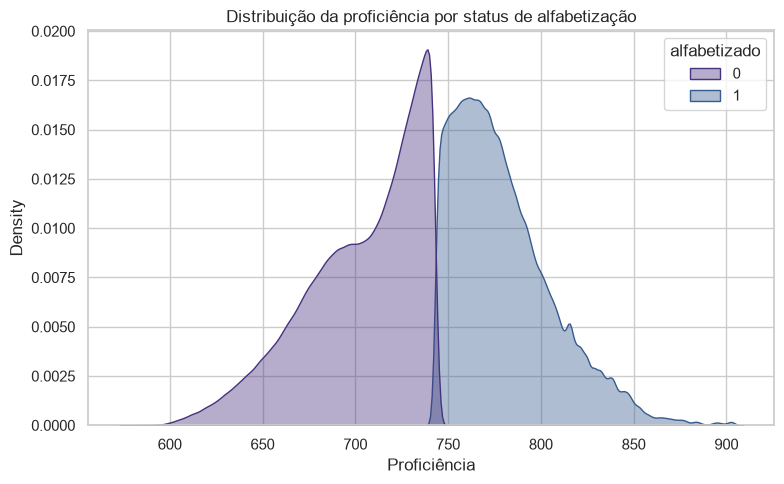

In [33]:
display(df_al_validos.groupby("alfabetizado")["proficiencia"].describe())

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_al_validos, x="proficiencia", hue="alfabetizado",
            fill=True, common_norm=False, alpha=0.4)
plt.title("Distribuição da proficiência por status de alfabetização")
plt.xlabel("Proficiência")
plt.tight_layout()
plt.show()

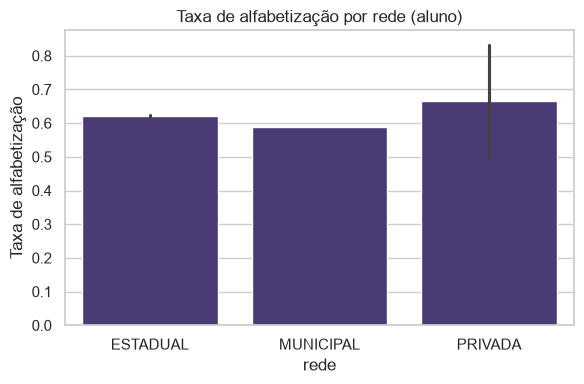

In [34]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_al_validos, x="rede", y="alfabetizado", errorbar=("ci", 95))
plt.title("Taxa de alfabetização por rede (aluno)")
plt.ylabel("Taxa de alfabetização")
plt.tight_layout()
plt.show()

In [39]:
cols_corr = ["taxa_alfabetizacao_real_escala_10", "total_alunos_avaliados",
             "meta_percentual_participacao", "media_proficiencia_alunos"]
cols_corr = [c for c in cols_corr if c in df_mun.columns]
corr = df_mun[cols_corr].corr(method="pearson")
corr.round(3)

,taxa_alfabetizacao_real_escala_10,total_alunos_avaliados,meta_percentual_participacao,media_proficiencia_alunos
taxa_alfabetizacao_real_escala_10,1.000,-0.042,0.231,0.927
total_alunos_avaliados,-0.042,1.000,-0.100,-0.044
meta_percentual_participacao,0.231,-0.100,1.000,0.290
media_proficiencia_alunos,0.927,-0.044,0.290,1.000


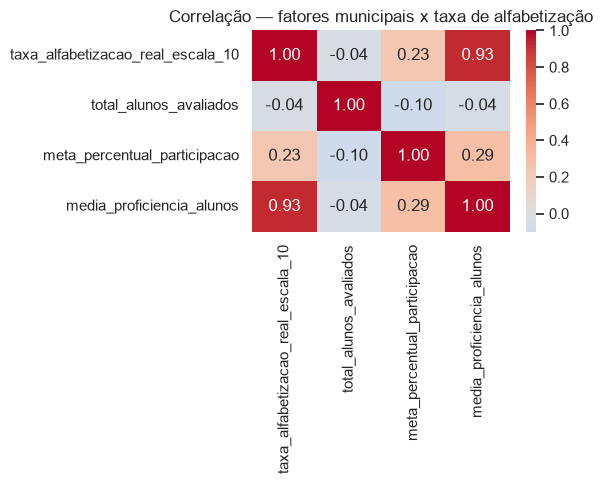

In [40]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação — fatores municipais x taxa de alfabetização")
plt.tight_layout()
plt.show()

In [41]:
df_mun.groupby("rede", observed=True)["taxa_alfabetizacao_real_escala_10"].agg(["mean", "median", "count"])

,mean,median,count
rede,,,
MUNICIPAL,6.199394,6.3,10031


In [42]:
tab_uf_simples = (
    df_mun.groupby("sigla_uf", observed=True)["taxa_alfabetizacao_real_escala_10"]
    .agg(n_municipios="count", taxa_media_simples="mean")
)

df_mun["_peso"] = df_mun["total_alunos_avaliados"]
df_mun["_taxa_x_peso"] = df_mun["taxa_alfabetizacao_real_escala_10"] * df_mun["_peso"]
tab_uf_ponderada = (
    df_mun.groupby("sigla_uf", observed=True)
    .apply(lambda g: g["_taxa_x_peso"].sum() / g["_peso"].sum(), include_groups=False)
    .rename("taxa_media_ponderada")
)

tab_uf = tab_uf_simples.join(tab_uf_ponderada).sort_values("taxa_media_ponderada", ascending=False)
tab_uf.round(2)

,n_municipios,taxa_media_simples,taxa_media_ponderada
sigla_uf,,,
CE,368,9.01,8.50
PR,795,7.52,7.22
GO,489,7.65,7.00
ES,156,7.60,6.96
SC,508,6.87,6.66
MG,1626,6.94,6.57
RO,104,6.67,6.44
PE,368,6.30,6.01
MT,279,6.26,5.86


In [43]:
tab_uf.sort_values("taxa_media_ponderada", ascending=False).head(10).round(2)

,n_municipios,taxa_media_simples,taxa_media_ponderada
sigla_uf,,,
CE,368,9.01,8.50
PR,795,7.52,7.22
GO,489,7.65,7.00
ES,156,7.60,6.96
SC,508,6.87,6.66
MG,1626,6.94,6.57
RO,104,6.67,6.44
PE,368,6.30,6.01
MT,279,6.26,5.86


In [44]:
tab_uf.sort_values("taxa_media_ponderada", ascending=True).head(10).round(2)

,n_municipios,taxa_media_simples,taxa_media_ponderada
sigla_uf,,,
SE,150,3.32,3.44
BA,796,3.74,3.67
RN,302,3.95,3.86
AP,32,4.60,4.59
TO,276,4.26,4.69
AL,204,4.95,4.70
PA,284,4.81,4.84
AM,110,4.68,4.88
AC,22,4.39,4.88


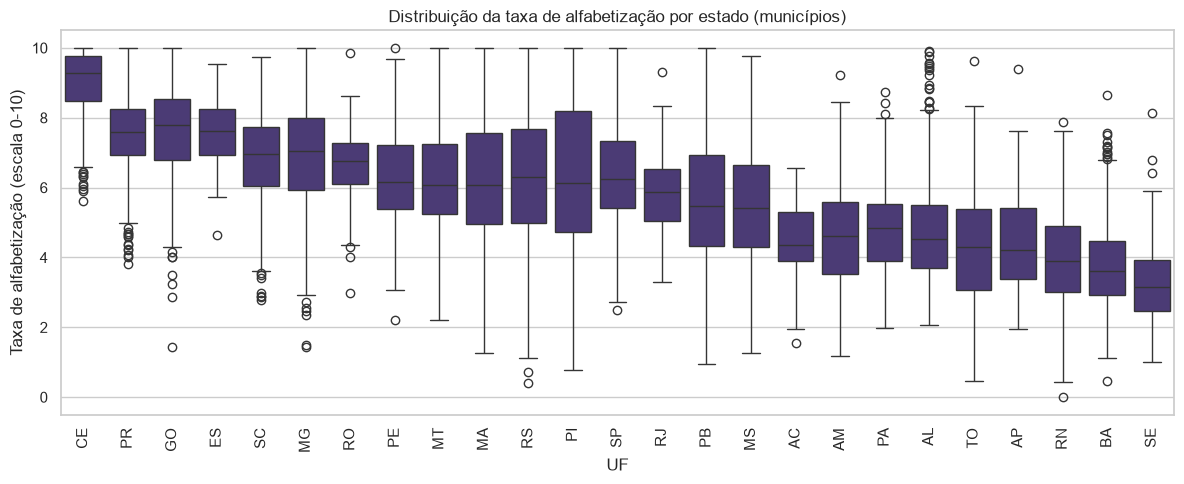

In [45]:
ordem_uf = tab_uf.sort_values("taxa_media_ponderada", ascending=False).index.tolist()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_mun, x="sigla_uf", y="taxa_alfabetizacao_real_escala_10", order=ordem_uf)
plt.xticks(rotation=90)
plt.title("Distribuição da taxa de alfabetização por estado (municípios)")
plt.xlabel("UF")
plt.ylabel("Taxa de alfabetização (escala 0-10)")
plt.tight_layout()
plt.show()